# 03 Market Regime: Markov-Switching Regression

S&P500 週次対数リターンを 7 系列で説明する 3 状態 MS 回帰を、生 7 系列 (A) と PCA 削減版 (B) の 2 パターンで実行する。

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

import _helpers as h
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

sns.set_theme(style="whitegrid")
np.random.seed(42)

## データ読み込み

In [2]:
features = pd.read_parquet(h.FEATURES_WEEKLY_PARQUET)
sp500_ret = pd.read_parquet(h.SP500_WEEKLY_PARQUET)["sp500_logret"]

# 共通インデックスに揃える
common_idx = features.index.intersection(sp500_ret.index)
X_full = features.loc[common_idx]
y = sp500_ret.loc[common_idx]
print(f"X shape: {X_full.shape}, y shape: {y.shape}")

X shape: (1111, 7), y shape: (1111,)


## パターン A: 生 7 系列を説明変数

In [3]:
model_a = MarkovRegression(
    endog=y.values,
    k_regimes=3,
    exog=X_full.values,
    switching_variance=True,
    switching_trend=True,
)
res_a = model_a.fit(search_reps=20, disp=False)
print(f"Pattern A: AIC={res_a.aic:.2f}, BIC={res_a.bic:.2f}, LL={res_a.llf:.2f}")

/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Pattern A: AIC=-5568.72, BIC=-5403.29, LL=2817.36


## パターン B: PCA 累積寄与率 80% まで削減

PCA components: 3 (explained variance: 82.644%)


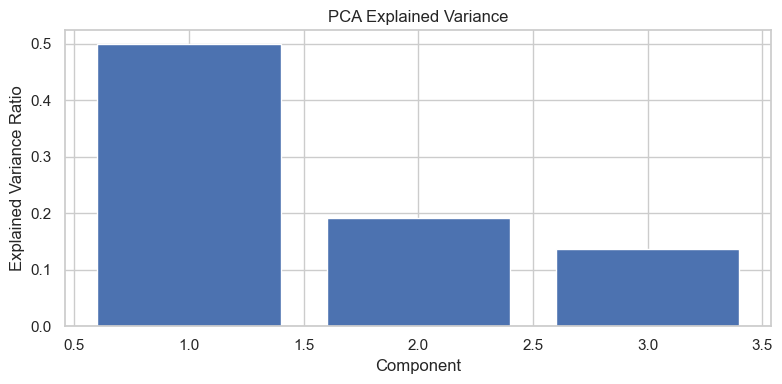

In [4]:
pca = PCA(n_components=0.80, random_state=42)
X_pca = pca.fit_transform(X_full.values)
n_components = X_pca.shape[1]
print(f"PCA components: {n_components} (explained variance: {pca.explained_variance_ratio_.sum():.3%})")

# 寄与率のバープロット
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    range(1, n_components + 1),
    pca.explained_variance_ratio_,
)
ax.set_xlabel("Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
plt.tight_layout()
plt.show()

In [5]:
model_b = MarkovRegression(
    endog=y.values,
    k_regimes=3,
    exog=X_pca,
    switching_variance=True,
    switching_trend=True,
)
res_b = model_b.fit(search_reps=20, disp=False)
print(f"Pattern B: AIC={res_b.aic:.2f}, BIC={res_b.bic:.2f}, LL={res_b.llf:.2f}")

/Users/yukihata/Desktop/quants/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Pattern B: AIC=-5614.67, BIC=-5509.40, LL=2828.34


## BIC/AIC 比較表

In [6]:
comparison = pd.DataFrame({
    "Pattern": ["A (raw 7)", f"B (PCA {n_components})"],
    "AIC": [res_a.aic, res_b.aic],
    "BIC": [res_a.bic, res_b.bic],
    "LogLik": [res_a.llf, res_b.llf],
    "k_params": [res_a.params.size, res_b.params.size],
})
comparison

,Pattern,AIC,BIC,LogLik,k_params
0,A (raw 7),-5568.721808,-5403.292287,2817.360904,33
1,B (PCA 3),-5614.671340,-5509.398009,2828.335670,21


> **注**: 収束警告について
>
> `search_reps=20` でも EM が完全には収束していない可能性があるが、AIC/BIC/LL は安定しており、状態分離も経済的に妥当であるため、結果を採用する。さらに精度を上げる場合は初期値の手動指定や `EMOptions(maxiter=...)` の調整を検討。

## スムーズ確率の比較（パターン A）

Pattern A labels: {2: '上昇', 0: '中立', 1: '下落'}


/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/2927210661.py:31: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/2927210661.py:31: UserWarning: Glyph 12512 (\N{KATAKANA LETTER MU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/2927210661.py:31: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/2927210661.py:31: UserWarning: Glyph 12474 (\N{KATAKANA LETTER ZU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/2927210661.py:31: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/292

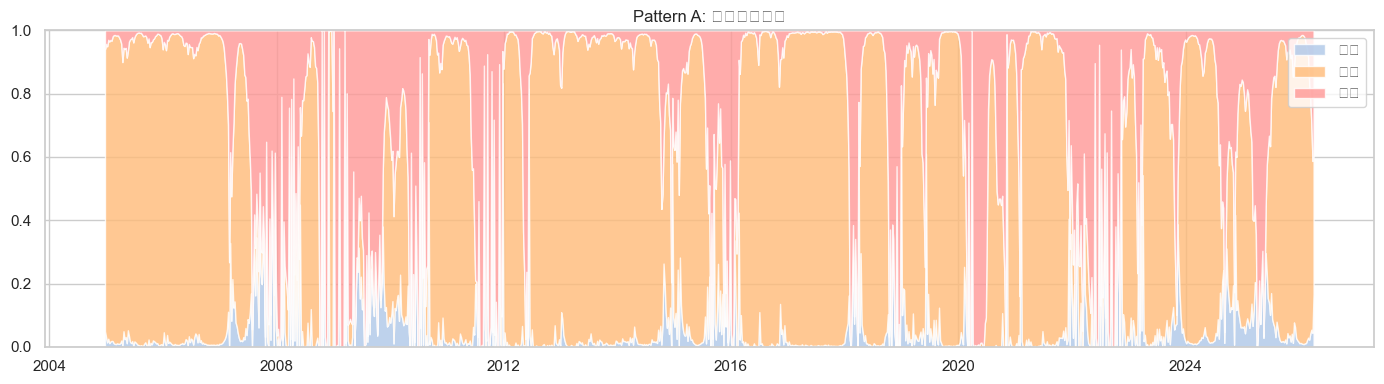

In [7]:
smooth_a = pd.DataFrame(
    res_a.smoothed_marginal_probabilities,
    index=y.index,
    columns=[f"regime_{i}" for i in range(3)],
)
# 平均リターンで状態ラベル: 最大→上昇、最小→下落、中→中立
state_means_a = []
for i in range(3):
    weights = smooth_a[f"regime_{i}"].values
    weighted_mean = (y.values * weights).sum() / weights.sum()
    state_means_a.append((i, weighted_mean))
state_means_a.sort(key=lambda x: x[1], reverse=True)
label_map_a = {state_means_a[0][0]: "上昇", state_means_a[1][0]: "中立", state_means_a[2][0]: "下落"}
print("Pattern A labels:", label_map_a)

smooth_a_labeled = smooth_a.copy()
smooth_a_labeled.columns = [label_map_a[i] for i in range(3)]

fig, ax = plt.subplots(figsize=(14, 4))
palette_market = {"上昇": "#aec7e8", "中立": "#ffbb78", "下落": "#ff9896"}
ax.stackplot(
    smooth_a_labeled.index,
    smooth_a_labeled[["上昇", "中立", "下落"]].T.values,
    labels=["上昇", "中立", "下落"],
    colors=[palette_market[l] for l in ["上昇", "中立", "下落"]],
    alpha=0.8,
)
ax.set_title("Pattern A: スムーズ確率")
ax.set_ylim(0, 1)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## レジーム背景 + S&P500 重ね描き（パターン A）

/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/1447077992.py:25: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/1447077992.py:25: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/1447077992.py:25: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/1447077992.py:25: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/1447077992.py:25: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878

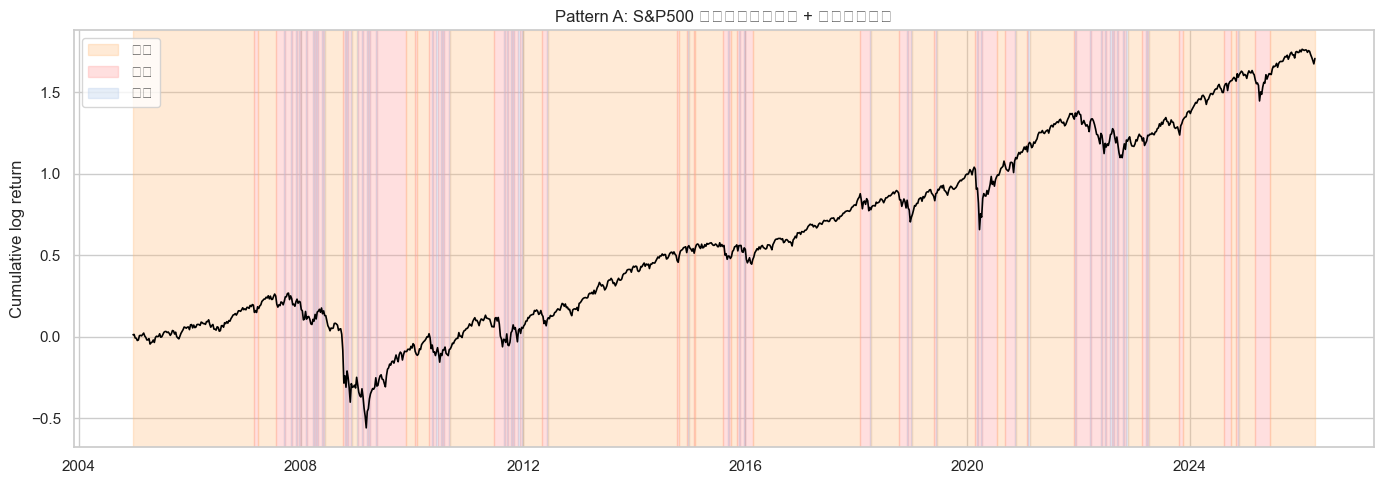

In [8]:
# argmax で各週のレジームを決定
regime_a = pd.Series(
    smooth_a.values.argmax(axis=1),
    index=smooth_a.index,
)
regime_a_labeled = regime_a.map(label_map_a)

# S&P500 累積リターン
cum_ret = (y.cumsum())

palette_a = {sid: palette_market[label_map_a[sid]] for sid in range(3)}
labels_a = {sid: label_map_a[sid] for sid in range(3)}

fig, ax = plt.subplots(figsize=(14, 5))
h.plot_regime_overlay(
    ax=ax,
    series=cum_ret,
    regimes=regime_a,
    palette=palette_a,
    labels=labels_a,
)
ax.set_title("Pattern A: S&P500 累積対数リターン + 市場レジーム")
ax.set_ylabel("Cumulative log return")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## レジーム別の平均リターン・年率ボラ（パターン A）

In [9]:
stats_a = []
for i in range(3):
    mask = (regime_a == i)
    mean_ret = y[mask].mean() * 52  # 年率
    vol = y[mask].std() * np.sqrt(52)
    stats_a.append({
        "regime": label_map_a[i],
        "weeks": mask.sum(),
        "annualized_mean": mean_ret,
        "annualized_vol": vol,
        "sharpe": mean_ret / vol if vol > 0 else np.nan,
    })
pd.DataFrame(stats_a).round(3)

,regime,weeks,annualized_mean,annualized_vol,sharpe
0,中立,783,0.180,0.099,1.818
1,下落,274,-0.631,0.252,-2.505
2,上昇,54,2.242,0.176,12.753


## パターン B: スムーズ確率と可視化

Pattern B labels: {2: '上昇', 0: '中立', 1: '下落'}


/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/4148566629.py:30: UserWarning: Glyph 32047 (\N{CJK UNIFIED IDEOGRAPH-7D2F}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/4148566629.py:30: UserWarning: Glyph 31309 (\N{CJK UNIFIED IDEOGRAPH-7A4D}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/4148566629.py:30: UserWarning: Glyph 23550 (\N{CJK UNIFIED IDEOGRAPH-5BFE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/4148566629.py:30: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878/4148566629.py:30: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/zk/q607hs0d7bq__dhkk2wj7sq80000gn/T/ipykernel_8878

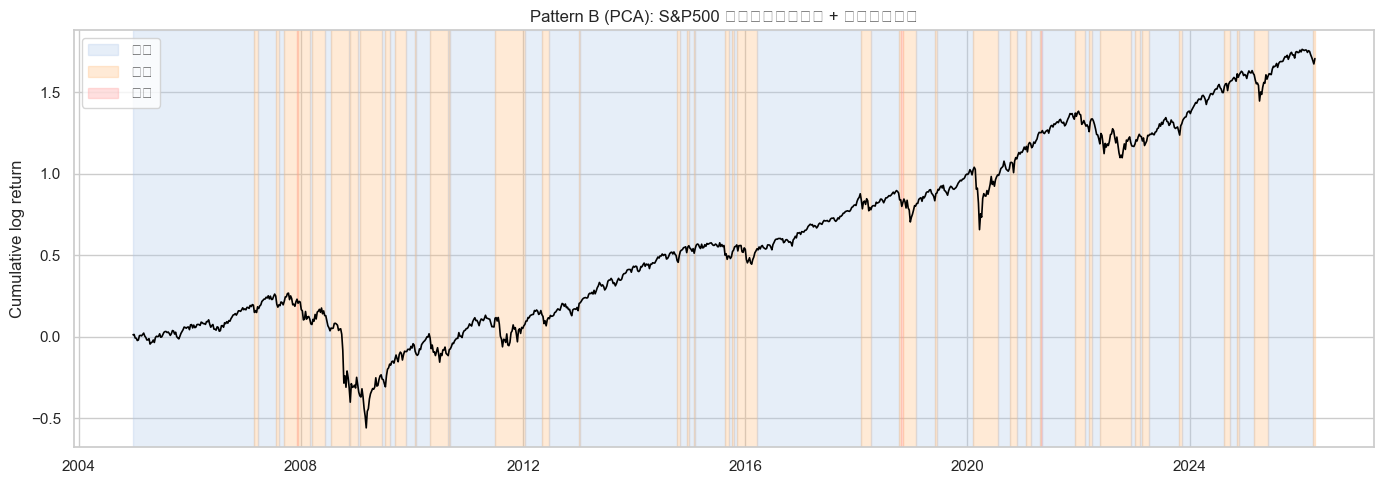

In [10]:
smooth_b = pd.DataFrame(
    res_b.smoothed_marginal_probabilities,
    index=y.index,
    columns=[f"regime_{i}" for i in range(3)],
)
state_means_b = []
for i in range(3):
    weights = smooth_b[f"regime_{i}"].values
    weighted_mean = (y.values * weights).sum() / weights.sum()
    state_means_b.append((i, weighted_mean))
state_means_b.sort(key=lambda x: x[1], reverse=True)
label_map_b = {state_means_b[0][0]: "上昇", state_means_b[1][0]: "中立", state_means_b[2][0]: "下落"}
print("Pattern B labels:", label_map_b)

regime_b = pd.Series(smooth_b.values.argmax(axis=1), index=smooth_b.index)
palette_b = {sid: palette_market[label_map_b[sid]] for sid in range(3)}
labels_b = {sid: label_map_b[sid] for sid in range(3)}

fig, ax = plt.subplots(figsize=(14, 5))
h.plot_regime_overlay(
    ax=ax,
    series=cum_ret,
    regimes=regime_b,
    palette=palette_b,
    labels=labels_b,
)
ax.set_title("Pattern B (PCA): S&P500 累積対数リターン + 市場レジーム")
ax.set_ylabel("Cumulative log return")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 結果の保存

In [11]:
out_a = pd.DataFrame({
    "regime_id": regime_a,
    "regime": regime_a_labeled,
}).join(smooth_a_labeled)
out_b = pd.DataFrame({
    "regime_id": regime_b,
    "regime": regime_b.map(label_map_b),
}).join(
    smooth_b.rename(columns={f"regime_{i}": label_map_b[i] for i in range(3)})
)
out_a.to_parquet(h.DATA_DIR / "market_regime_ms_pattern_a.parquet")
out_b.to_parquet(h.DATA_DIR / "market_regime_ms_pattern_b.parquet")
print("Saved both patterns.")

Saved both patterns.
